# OECT Local Dataset ML Analysis — DSP Sensitivity Version

This notebook repeats the corrected local OECT relaxed/stressed analysis and adds:

1. **Bandpass comparison** — several OECT-oriented frequency ranges are evaluated.
2. **Window-size comparison** — several segmentation lengths are evaluated.
3. **Grouped cross-validation by recording file** — all windows from the same `.txt` recording stay either in train or in test.
4. **Recording-level majority voting** — window predictions are aggregated into one prediction per recording.

Main local task:

- `relaxed` → low arousal → class 0
- `stressed` → high arousal → class 1

The results should be interpreted as **pilot feasibility evidence**, not as a final generalizable classifier.


In [1]:

import os
import re
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal, stats
from scipy.integrate import trapezoid

from sklearn.model_selection import StratifiedGroupKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Paths

The notebook expects `Dataset.zip` in `/mnt/data/` or an already extracted dataset folder. Change paths if needed.

In [2]:
DATA_DIR = Path("./Dataset")
OUTPUT_DIR = Path("./outputs")

if not DATA_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    if ZIP_PATH.exists():
        with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
    else:
        raise FileNotFoundError('Dataset.zip was not found. Please update ZIP_PATH or DATA_DIR.')

print('DATA_DIR:', DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('Number of txt files:', len(list(DATA_DIR.rglob('*.txt'))))


DATA_DIR: Dataset
OUTPUT_DIR: outputs
Number of txt files: 26


## 2. Metadata from filenames

Only `relaxed` and `stressed` recordings are used in the main supervised local classification task.

In [3]:

def infer_subject_condition(path: Path):
    name = path.stem
    subject = name.split('_')[0]
    lower = name.lower()
    if 'relaxed' in lower:
        condition = 'relaxed'
        label = 0
    elif 'stressed' in lower:
        condition = 'stressed'
        label = 1
    elif 'positive' in lower:
        condition = 'positive'
        label = np.nan
    elif 'brain' in lower:
        condition = 'brain'
        label = np.nan
    else:
        condition = 'unknown'
        label = np.nan
    return subject, condition, label

rows = []
for path in sorted(DATA_DIR.rglob('*.txt')):
    subject, condition, label = infer_subject_condition(path)
    rows.append({
        'file_name': path.name,
        'file_path': str(path),
        'subject_id': subject,
        'condition': condition,
        'label_arousal': label,
    })

metadata = pd.DataFrame(rows)
metadata.to_csv(OUTPUT_DIR / 'metadata_all_files.csv', index=False)

labeled_meta = metadata[metadata['condition'].isin(['relaxed', 'stressed'])].copy()
labeled_meta['label_arousal'] = labeled_meta['label_arousal'].astype(int)
labeled_meta.to_csv(OUTPUT_DIR / 'metadata_labeled_relaxed_stressed.csv', index=False)

print('All files by condition:')
print(metadata['condition'].value_counts())
print('\nFiles used for supervised local classification:')
print(labeled_meta['condition'].value_counts())
display(labeled_meta[['file_name', 'subject_id', 'condition', 'label_arousal']])


All files by condition:
condition
relaxed     15
stressed     9
positive     2
Name: count, dtype: int64

Files used for supervised local classification:
condition
relaxed     15
stressed     9
Name: count, dtype: int64


,file_name,subject_id,condition,label_arousal
0,S01_relaxed.txt,S01,relaxed,0
1,S01_relaxed2.txt,S01,relaxed,0
2,S01_stressed.txt,S01,stressed,1
3,S01_stressed2.txt,S01,stressed,1
4,S02_relaxed.txt,S02,relaxed,0
5,S02_relaxed1.txt,S02,relaxed,0
6,S02_relaxed2.txt,S02,relaxed,0
7,S02_stressed.txt,S02,stressed,1
8,S03_relaxed.txt,S03,relaxed,0
9,S03_relaxed_2.txt,S03,relaxed,0


## 3. Loading, preprocessing, segmentation, and feature extraction

The signal is read from `WE(1).Current (A)` and the time axis from `Corrected time (s)`. The `.txt` files use semicolon separators and decimal commas.

The preprocessing is **OECT-oriented**:

- transient removal;
- linear detrending;
- bandpass filtering;
- optional per-recording z-score normalization;
- window segmentation.


In [4]:

TRANSIENT_SEC = 3.0
OVERLAP = 0.50
NORMALIZE_PER_RECORDING = True
FILTER_ORDER = 4

# OECT-inspired spectral ranges. The highest band is clipped automatically
# if the selected bandpass upper frequency is lower than the band boundary.
FREQ_BANDS = {
    'band_0p05_0p5': (0.05, 0.5),
    'band_0p5_1': (0.5, 1.0),
    'band_0p5_4': (0.5, 4.0),
    'band_4_8': (4.0, 8.0),
    'band_8_13': (8.0, 13.0),
    'band_13_20': (13.0, 20.0),
}


def load_oect_txt(path):
    df = pd.read_csv(path, sep=';', decimal=',')
    time_col = 'Corrected time (s)' if 'Corrected time (s)' in df.columns else 'Time (s)'
    current_col = 'WE(1).Current (A)'
    if current_col not in df.columns:
        raise ValueError(f'Missing current column in {path}')
    t = df[time_col].to_numpy(dtype=float)
    x = df[current_col].to_numpy(dtype=float)
    mask = np.isfinite(t) & np.isfinite(x)
    t = t[mask]
    x = x[mask]
    order = np.argsort(t)
    return t[order], x[order]


def estimate_fs(t):
    dt = np.median(np.diff(t))
    if dt <= 0:
        raise ValueError('Non-positive median dt encountered')
    return float(1.0 / dt)


def preprocess_oect(t, x, bp_low=0.05, bp_high=20.0, transient_sec=TRANSIENT_SEC):
    fs = estimate_fs(t)
    keep = t >= (t[0] + transient_sec)
    t2 = t[keep] - t[keep][0]
    x2 = x[keep]
    if len(x2) < int(fs * 5):
        raise ValueError('Recording too short after transient removal')

    # Remove slow linear drift before filtering.
    x2 = signal.detrend(x2, type='linear')

    nyq = fs / 2.0
    high = min(bp_high, nyq * 0.95)
    low = max(bp_low, 1e-4)
    if not (0 < low < high < nyq):
        raise ValueError(f'Invalid bandpass: low={low}, high={high}, fs={fs}')
    sos = signal.butter(FILTER_ORDER, [low / nyq, high / nyq], btype='bandpass', output='sos')
    xf = signal.sosfiltfilt(sos, x2)

    if NORMALIZE_PER_RECORDING:
        xf = (xf - np.mean(xf)) / (np.std(xf) + 1e-12)

    return t2, xf, fs


def segment_signal(x, fs, window_sec=5.0, overlap=OVERLAP):
    win = int(round(window_sec * fs))
    step = int(round(win * (1.0 - overlap)))
    if win <= 0 or step <= 0:
        raise ValueError('Invalid window/step length')
    segments, starts = [], []
    for start in range(0, len(x) - win + 1, step):
        segments.append(x[start:start+win])
        starts.append(start / fs)
    if len(segments) == 0:
        return np.empty((0, win)), np.array([])
    return np.asarray(segments), np.asarray(starts)


def hjorth_parameters(x):
    dx = np.diff(x)
    ddx = np.diff(dx)
    var_x = np.var(x)
    var_dx = np.var(dx)
    var_ddx = np.var(ddx)
    activity = var_x
    mobility = np.sqrt(var_dx / (var_x + 1e-12))
    complexity = np.sqrt(var_ddx / (var_dx + 1e-12)) / (mobility + 1e-12)
    return float(activity), float(mobility), float(complexity)


def bandpower_from_psd(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs < fmax)
    if mask.sum() < 2:
        return 0.0
    return float(trapezoid(psd[mask], freqs[mask]))


def spectral_entropy(psd):
    p = psd / (np.sum(psd) + 1e-12)
    p = p[p > 0]
    if len(p) <= 1:
        return 0.0
    return float(-np.sum(p * np.log2(p)) / np.log2(len(p)))


def extract_features(x, fs, bp_low=0.05, bp_high=20.0):
    feats = {}
    feats['mean'] = float(np.mean(x))
    feats['std'] = float(np.std(x))
    feats['variance'] = float(np.var(x))
    feats['rms'] = float(np.sqrt(np.mean(x**2)))
    feats['min'] = float(np.min(x))
    feats['max'] = float(np.max(x))
    feats['ptp'] = float(np.ptp(x))
    feats['median'] = float(np.median(x))
    feats['iqr'] = float(stats.iqr(x))
    feats['skewness'] = float(stats.skew(x, bias=False))
    feats['kurtosis'] = float(stats.kurtosis(x, bias=False))
    feats['energy'] = float(np.sum(x**2))
    feats['mav'] = float(np.mean(np.abs(x)))
    feats['line_length'] = float(np.sum(np.abs(np.diff(x))))
    feats['zero_crossing_rate'] = float(np.mean(np.diff(np.signbit(x)) != 0))

    h_act, h_mob, h_comp = hjorth_parameters(x)
    feats['hjorth_activity'] = h_act
    feats['hjorth_mobility'] = h_mob
    feats['hjorth_complexity'] = h_comp

    nperseg = min(len(x), int(round(4 * fs)))
    freqs, psd = signal.welch(x, fs=fs, nperseg=nperseg)
    total_power = bandpower_from_psd(freqs, psd, bp_low, bp_high)
    feats[f'total_power_{str(bp_low).replace(".", "p")}_{str(bp_high).replace(".", "p")}'] = total_power
    feats['spectral_entropy'] = spectral_entropy(psd)

    for name, (fmin, fmax) in FREQ_BANDS.items():
        # Do not interpret a band outside the selected preprocessing range.
        clipped_min = max(fmin, bp_low)
        clipped_max = min(fmax, bp_high)
        if clipped_max <= clipped_min:
            bp = 0.0
        else:
            bp = bandpower_from_psd(freqs, psd, clipped_min, clipped_max)
        feats[name + '_power'] = bp
        feats[name + '_relative_power'] = bp / (total_power + 1e-12)

    return feats


## 4. Build a feature table for a selected DSP configuration

In [5]:

def build_feature_table(bp_low=0.05, bp_high=20.0, window_sec=5.0):
    feature_rows = []
    recording_rows = []

    for _, row in labeled_meta.iterrows():
        t, x = load_oect_txt(row['file_path'])
        duration_raw = float(t[-1] - t[0])
        fs = estimate_fs(t)
        t_proc, x_proc, fs_proc = preprocess_oect(t, x, bp_low=bp_low, bp_high=bp_high)
        segments, starts = segment_signal(x_proc, fs_proc, window_sec=window_sec)

        recording_rows.append({
            'file_name': row['file_name'],
            'subject_id': row['subject_id'],
            'condition': row['condition'],
            'label_arousal': row['label_arousal'],
            'duration_raw_s': duration_raw,
            'fs_hz': fs,
            'n_samples_raw': len(x),
            'n_samples_processed': len(x_proc),
            'n_windows': len(segments),
            'bp_low': bp_low,
            'bp_high': bp_high,
            'window_sec': window_sec,
        })

        for i, seg in enumerate(segments):
            feats = extract_features(seg, fs_proc, bp_low=bp_low, bp_high=bp_high)
            feats.update({
                'file_name': row['file_name'],
                'subject_id': row['subject_id'],
                'condition': row['condition'],
                'label_arousal': row['label_arousal'],
                'window_id': i,
                'window_start_s': starts[i],
                'bp_low': bp_low,
                'bp_high': bp_high,
                'window_sec': window_sec,
            })
            feature_rows.append(feats)

    window_features = pd.DataFrame(feature_rows)
    recording_summary = pd.DataFrame(recording_rows)

    id_cols = ['file_name', 'subject_id', 'condition', 'label_arousal', 'window_id',
               'window_start_s', 'bp_low', 'bp_high', 'window_sec']
    feature_cols = [c for c in window_features.columns if c not in id_cols]

    # Ensure there are no inf values. Replace remaining NaNs with feature medians.
    window_features[feature_cols] = window_features[feature_cols].replace([np.inf, -np.inf], np.nan)
    med = window_features[feature_cols].median(numeric_only=True)
    window_features[feature_cols] = window_features[feature_cols].fillna(med).fillna(0.0)

    return window_features, recording_summary, feature_cols

# Default configuration used as a baseline.
DEFAULT_BP_LOW = 0.05
DEFAULT_BP_HIGH = 20.0
DEFAULT_WINDOW_SEC = 5.0

window_features, recording_summary, feature_cols = build_feature_table(
    bp_low=DEFAULT_BP_LOW,
    bp_high=DEFAULT_BP_HIGH,
    window_sec=DEFAULT_WINDOW_SEC,
)

window_features.to_csv(OUTPUT_DIR / 'default_window_features.csv', index=False)
recording_summary.to_csv(OUTPUT_DIR / 'default_recording_summary.csv', index=False)

print('Default window-level feature table:', window_features.shape)
print('Number of features:', len(feature_cols))
print('\nRecording summary:')
display(recording_summary)
print('\nWindows by class:')
print(window_features['condition'].value_counts())


Default window-level feature table: (216, 41)
Number of features: 32

Recording summary:


,file_name,subject_id,condition,label_arousal,duration_raw_s,fs_hz,n_samples_raw,n_samples_processed,n_windows,bp_low,bp_high,window_sec
0,S01_relaxed.txt,S01,relaxed,0,29.9975,400.000001,12000,10799,9,0.05,20.0,5.0
1,S01_relaxed2.txt,S01,relaxed,0,29.9975,400.000001,12000,10799,9,0.05,20.0,5.0
2,S01_stressed.txt,S01,stressed,1,29.9975,400.000001,12000,10799,9,0.05,20.0,5.0
3,S01_stressed2.txt,S01,stressed,1,29.9975,400.000001,12000,10799,9,0.05,20.0,5.0
4,S02_relaxed.txt,S02,relaxed,0,29.9975,400.000001,12000,10799,9,0.05,20.0,5.0
5,S02_relaxed1.txt,S02,relaxed,0,29.9975,400.000001,12000,10799,9,0.05,20.0,5.0
6,S02_relaxed2.txt,S02,relaxed,0,29.9975,400.000001,12000,10799,9,0.05,20.0,5.0
7,S02_stressed.txt,S02,stressed,1,29.9975,400.000001,12000,10799,9,0.05,20.0,5.0
8,S03_relaxed.txt,S03,relaxed,0,29.9975,400.000001,12000,10799,9,0.05,20.0,5.0
9,S03_relaxed_2.txt,S03,relaxed,0,29.9975,400.000001,12000,10799,9,0.05,20.0,5.0



Windows by class:
condition
relaxed     135
stressed     81
Name: count, dtype: int64


## 5. Grouped cross-validation and recording-level voting

Two metrics are reported:

1. **Window-level metrics** — predictions are evaluated for individual windows.
2. **Recording-level metrics** — window predictions are aggregated by majority vote for each `.txt` recording.

The final recording-level view is often more meaningful because each file represents one experimental recording.


In [6]:

def make_models(k_features=None):
    # Feature selection is optional. If used, it is placed inside the Pipeline,
    # so it is fitted only on training folds and does not leak test information.
    def steps(clf, use_scaler=True):
        s = []
        if use_scaler:
            s.append(('scaler', StandardScaler()))
        if k_features is not None:
            s.append(('select', SelectKBest(score_func=f_classif, k=k_features)))
        s.append(('clf', clf))
        return Pipeline(s)

    return {
        'Logistic Regression': steps(LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
        'SVM RBF': steps(SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=RANDOM_STATE)),
        'Random Forest': steps(RandomForestClassifier(n_estimators=100, max_depth=None, class_weight='balanced', random_state=RANDOM_STATE), use_scaler=False),
        'Extra Trees': steps(ExtraTreesClassifier(n_estimators=100, max_depth=None, class_weight='balanced', random_state=RANDOM_STATE), use_scaler=False),
        'kNN': steps(KNeighborsClassifier(n_neighbors=5)),
    }


def majority_vote(labels):
    counts = Counter(labels)
    # Tie-breaking: choose the smaller label for deterministic behavior.
    return sorted(counts.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]


def evaluate_models(window_features, feature_cols, n_splits=5, k_features=None, model_subset=None):
    X = window_features[feature_cols].to_numpy(dtype=float)
    y = window_features['label_arousal'].to_numpy(dtype=int)
    groups = window_features['file_name'].to_numpy()

    unique_files = pd.DataFrame({
        'file_name': window_features['file_name'],
        'label_arousal': window_features['label_arousal'],
        'condition': window_features['condition']
    }).drop_duplicates('file_name')

    min_class_files = unique_files['label_arousal'].value_counts().min()
    n_splits_eff = min(n_splits, int(min_class_files))
    if n_splits_eff < 2:
        raise ValueError('Not enough files per class for grouped CV')

    cv = StratifiedGroupKFold(n_splits=n_splits_eff, shuffle=True, random_state=RANDOM_STATE)
    models = make_models(k_features=k_features)
    if model_subset is not None:
        models = {k: v for k, v in models.items() if k in model_subset}

    rows = []
    predictions = {}

    for name, model in models.items():
        y_pred = cross_val_predict(model, X, y, cv=cv, groups=groups)

        # Window-level metrics
        win_acc = accuracy_score(y, y_pred)
        win_f1_macro = f1_score(y, y_pred, average='macro', zero_division=0)
        win_precision_macro = precision_score(y, y_pred, average='macro', zero_division=0)
        win_recall_macro = recall_score(y, y_pred, average='macro', zero_division=0)
        win_f1_stressed = f1_score(y, y_pred, pos_label=1, zero_division=0)

        pred_df = window_features[['file_name', 'label_arousal', 'condition']].copy()
        pred_df['y_pred'] = y_pred
        file_pred = pred_df.groupby('file_name').agg(
            y_true=('label_arousal', 'first'),
            condition=('condition', 'first'),
            y_pred_file=('y_pred', majority_vote),
            n_windows=('y_pred', 'size')
        ).reset_index()

        file_acc = accuracy_score(file_pred['y_true'], file_pred['y_pred_file'])
        file_f1_macro = f1_score(file_pred['y_true'], file_pred['y_pred_file'], average='macro', zero_division=0)
        file_precision_macro = precision_score(file_pred['y_true'], file_pred['y_pred_file'], average='macro', zero_division=0)
        file_recall_macro = recall_score(file_pred['y_true'], file_pred['y_pred_file'], average='macro', zero_division=0)
        file_f1_stressed = f1_score(file_pred['y_true'], file_pred['y_pred_file'], pos_label=1, zero_division=0)

        rows.append({
            'model': name,
            'n_splits': n_splits_eff,
            'k_features': k_features if k_features is not None else 'all',
            'window_accuracy': win_acc,
            'window_macro_f1': win_f1_macro,
            'window_macro_precision': win_precision_macro,
            'window_macro_recall': win_recall_macro,
            'window_f1_stressed': win_f1_stressed,
            'file_accuracy': file_acc,
            'file_macro_f1': file_f1_macro,
            'file_macro_precision': file_precision_macro,
            'file_macro_recall': file_recall_macro,
            'file_f1_stressed': file_f1_stressed,
        })
        predictions[name] = {'window_pred': y_pred, 'file_pred': file_pred}

    return pd.DataFrame(rows).sort_values(['file_macro_f1', 'window_macro_f1'], ascending=False), predictions


## 6. Default baseline results

,model,n_splits,k_features,window_accuracy,window_macro_f1,window_macro_precision,window_macro_recall,window_f1_stressed,file_accuracy,file_macro_f1,file_macro_precision,file_macro_recall,file_f1_stressed
2,Random Forest,5,all,0.814815,0.800425,0.803980,0.797531,0.746835,0.833333,0.822222,0.822222,0.822222,0.777778
3,Extra Trees,5,all,0.777778,0.759197,0.764255,0.755556,0.692308,0.833333,0.822222,0.822222,0.822222,0.777778
0,Logistic Regression,5,all,0.699074,0.690960,0.690862,0.702469,0.640884,0.708333,0.703704,0.708333,0.722222,0.666667
1,SVM RBF,5,all,0.583333,0.581034,0.597072,0.602469,0.550000,0.625000,0.624348,0.650000,0.655556,0.608696
4,kNN,5,all,0.560185,0.542036,0.542602,0.544444,0.450867,0.625000,0.590133,0.593750,0.588889,0.470588


Best default model by recording-level macro F1: Random Forest


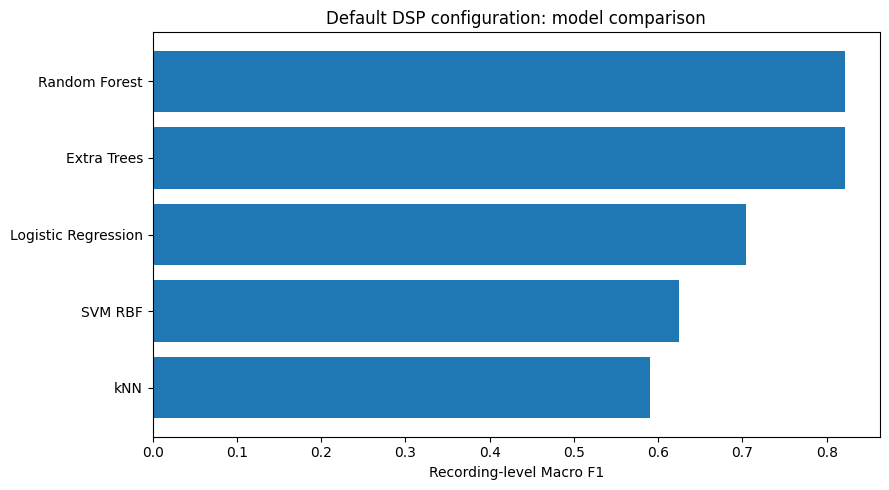

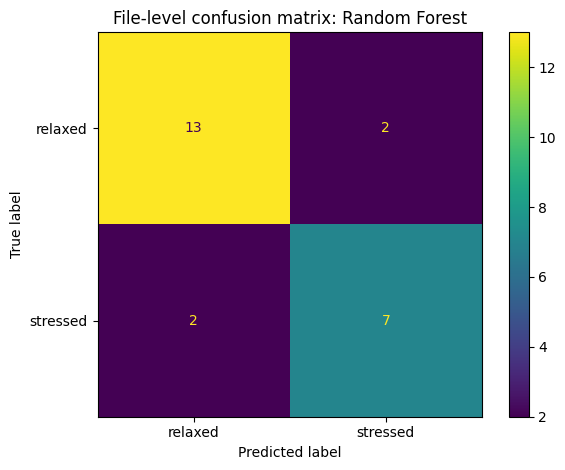

              precision    recall  f1-score   support

     relaxed       0.87      0.87      0.87        15
    stressed       0.78      0.78      0.78         9

    accuracy                           0.83        24
   macro avg       0.82      0.82      0.82        24
weighted avg       0.83      0.83      0.83        24



In [7]:

default_results, default_predictions = evaluate_models(
    window_features,
    feature_cols,
    n_splits=5,
    k_features=None,
)

default_results.to_csv(OUTPUT_DIR / 'default_grouped_cv_results.csv', index=False)
display(default_results)

best_default_model = default_results.iloc[0]['model']
print('Best default model by recording-level macro F1:', best_default_model)

# Plot default model comparison
plt.figure(figsize=(9, 5))
plot_df = default_results.sort_values('file_macro_f1')
plt.barh(plot_df['model'], plot_df['file_macro_f1'])
plt.xlabel('Recording-level Macro F1')
plt.title('Default DSP configuration: model comparison')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'default_model_comparison_file_macro_f1.png', dpi=200)
plt.show()

# Confusion matrix for the best default model at file level
file_pred = default_predictions[best_default_model]['file_pred']
cm = confusion_matrix(file_pred['y_true'], file_pred['y_pred_file'], labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['relaxed', 'stressed'])
disp.plot(values_format='d')
plt.title(f'File-level confusion matrix: {best_default_model}')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'default_best_model_file_confusion_matrix.png', dpi=200)
plt.show()

print(classification_report(file_pred['y_true'], file_pred['y_pred_file'], target_names=['relaxed', 'stressed'], zero_division=0))


## 8. Bandpass comparison

The default window size is kept at 5 seconds. Several candidate OECT-oriented bandpass ranges are compared.


,bp_low,bp_high,model,file_accuracy,file_macro_f1,window_accuracy,window_macro_f1,n_windows
0,0.05,10.0,Extra Trees,0.833333,0.822222,0.736111,0.713241,216
3,0.05,20.0,Random Forest,0.833333,0.822222,0.814815,0.800425,216
6,0.10,20.0,Extra Trees,0.708333,0.695100,0.643519,0.618803,216
9,0.50,20.0,Random Forest,0.583333,0.495798,0.495370,0.407951,216


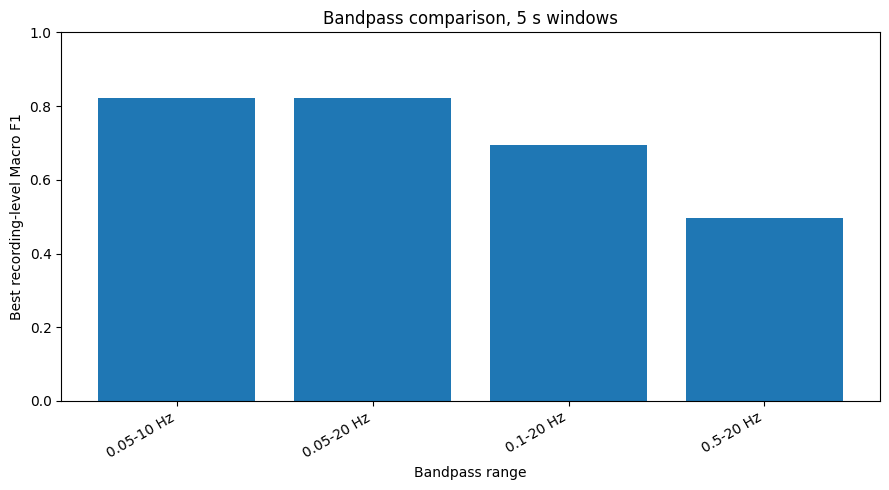

In [8]:

BANDPASS_CONFIGS = [
    (0.05, 10.0),
    (0.05, 20.0),
    (0.10, 20.0),
    (0.50, 20.0),
]

bandpass_rows = []
for bp_low, bp_high in BANDPASS_CONFIGS:
    wf, rs, fc = build_feature_table(bp_low=bp_low, bp_high=bp_high, window_sec=DEFAULT_WINDOW_SEC)
    res, _ = evaluate_models(wf, fc, n_splits=5, k_features=None, model_subset=['Logistic Regression', 'Random Forest', 'Extra Trees'])
    res['bp_low'] = bp_low
    res['bp_high'] = bp_high
    res['window_sec'] = DEFAULT_WINDOW_SEC
    res['n_windows'] = len(wf)
    bandpass_rows.append(res)

bandpass_results = pd.concat(bandpass_rows, ignore_index=True)
bandpass_results.to_csv(OUTPUT_DIR / 'bandpass_comparison_all_models.csv', index=False)

# Best model for each bandpass configuration
bandpass_best = (bandpass_results
                 .sort_values(['bp_low', 'bp_high', 'file_macro_f1', 'window_macro_f1'], ascending=[True, True, False, False])
                 .groupby(['bp_low', 'bp_high'], as_index=False)
                 .head(1)
                 .sort_values('file_macro_f1', ascending=False))
bandpass_best.to_csv(OUTPUT_DIR / 'bandpass_comparison_best_per_config.csv', index=False)
display(bandpass_best[['bp_low', 'bp_high', 'model', 'file_accuracy', 'file_macro_f1', 'window_accuracy', 'window_macro_f1', 'n_windows']])

# Plot best file-level macro F1 by bandpass
labels = [f'{r.bp_low:g}-{r.bp_high:g} Hz' for _, r in bandpass_best.sort_values(['bp_low','bp_high']).iterrows()]
values = bandpass_best.sort_values(['bp_low','bp_high'])['file_macro_f1'].to_numpy()
plt.figure(figsize=(9, 5))
plt.bar(labels, values)
plt.ylabel('Best recording-level Macro F1')
plt.xlabel('Bandpass range')
plt.title('Bandpass comparison, 5 s windows')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bandpass_comparison_best_file_macro_f1.png', dpi=200)
plt.show()


## 9. Window-size comparison

The default bandpass is kept at 0.05–20 Hz. Several window sizes are compared.


,window_sec,model,file_accuracy,file_macro_f1,window_accuracy,window_macro_f1,n_windows
0,3.0,Random Forest,0.833333,0.822222,0.783854,0.767098,384
3,5.0,Random Forest,0.833333,0.822222,0.814815,0.800425,216
6,8.0,Random Forest,0.833333,0.822222,0.808333,0.794628,120


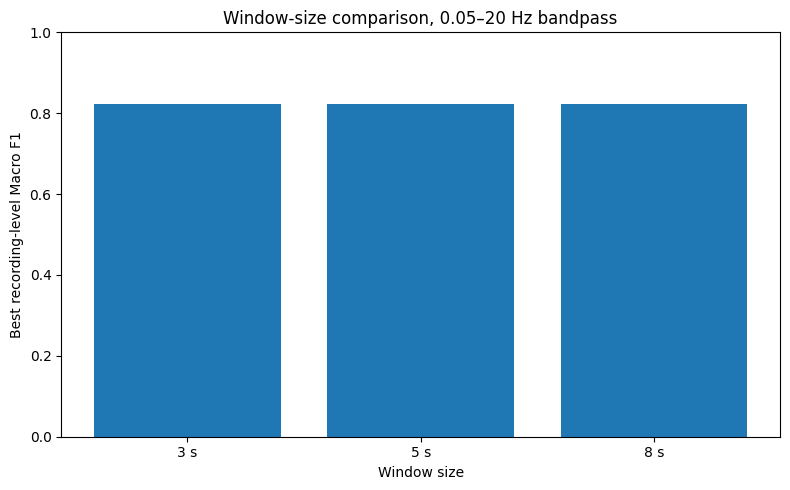

In [9]:

WINDOW_CONFIGS = [3.0, 5.0, 8.0]

window_rows = []
for window_sec in WINDOW_CONFIGS:
    wf, rs, fc = build_feature_table(bp_low=DEFAULT_BP_LOW, bp_high=DEFAULT_BP_HIGH, window_sec=window_sec)
    res, _ = evaluate_models(wf, fc, n_splits=5, k_features=None, model_subset=['Logistic Regression', 'Random Forest', 'Extra Trees'])
    res['bp_low'] = DEFAULT_BP_LOW
    res['bp_high'] = DEFAULT_BP_HIGH
    res['window_sec'] = window_sec
    res['n_windows'] = len(wf)
    window_rows.append(res)

window_results = pd.concat(window_rows, ignore_index=True)
window_results.to_csv(OUTPUT_DIR / 'window_size_comparison_all_models.csv', index=False)

window_best = (window_results
               .sort_values(['window_sec', 'file_macro_f1', 'window_macro_f1'], ascending=[True, False, False])
               .groupby('window_sec', as_index=False)
               .head(1)
               .sort_values('file_macro_f1', ascending=False))
window_best.to_csv(OUTPUT_DIR / 'window_size_comparison_best_per_config.csv', index=False)
display(window_best[['window_sec', 'model', 'file_accuracy', 'file_macro_f1', 'window_accuracy', 'window_macro_f1', 'n_windows']])

labels = [f'{w:g} s' for w in window_best.sort_values('window_sec')['window_sec']]
values = window_best.sort_values('window_sec')['file_macro_f1'].to_numpy()
plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.ylabel('Best recording-level Macro F1')
plt.xlabel('Window size')
plt.title('Window-size comparison, 0.05–20 Hz bandpass')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'window_size_comparison_best_file_macro_f1.png', dpi=200)
plt.show()


## 10. Final recommended configuration from bandpass/window comparisons

The cell below selects the best configuration among the one-factor comparisons: bandpass search with 5 s windows and window-size search with 0.05–20 Hz bandpass. This is intentionally conservative and fast to run.

Best tested DSP/model configuration from one-factor comparisons:


,model,n_splits,k_features,window_accuracy,window_macro_f1,window_macro_precision,window_macro_recall,window_f1_stressed,file_accuracy,file_macro_f1,file_macro_precision,file_macro_recall,file_f1_stressed,bp_low,bp_high,window_sec,n_windows
3,Random Forest,5,all,0.814815,0.800425,0.80398,0.797531,0.746835,0.833333,0.822222,0.822222,0.822222,0.777778,0.05,20.0,5.0,216



Best configuration evaluation:


,model,n_splits,k_features,window_accuracy,window_macro_f1,window_macro_precision,window_macro_recall,window_f1_stressed,file_accuracy,file_macro_f1,file_macro_precision,file_macro_recall,file_f1_stressed
0,Random Forest,5,all,0.814815,0.800425,0.80398,0.797531,0.746835,0.833333,0.822222,0.822222,0.822222,0.777778


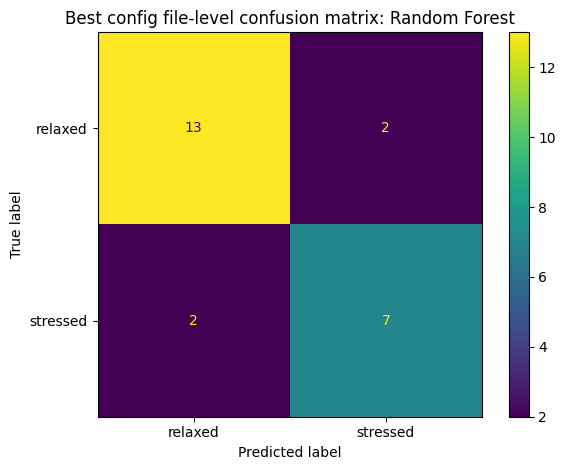

              precision    recall  f1-score   support

     relaxed       0.87      0.87      0.87        15
    stressed       0.78      0.78      0.78         9

    accuracy                           0.83        24
   macro avg       0.82      0.82      0.82        24
weighted avg       0.83      0.83      0.83        24



In [10]:

# Combine the best results from the separate bandpass and window-size comparisons.
candidate_results = pd.concat([bandpass_results, window_results], ignore_index=True)
final_best = candidate_results.sort_values(['file_macro_f1', 'window_macro_f1'], ascending=False).iloc[0]
print('Best tested DSP/model configuration from one-factor comparisons:')
display(final_best.to_frame().T)

best_bp_low = float(final_best['bp_low'])
best_bp_high = float(final_best['bp_high'])
best_window_sec = float(final_best['window_sec'])
best_model_name = final_best['model']

best_wf, best_rs, best_fc = build_feature_table(bp_low=best_bp_low, bp_high=best_bp_high, window_sec=best_window_sec)
best_res, best_preds = evaluate_models(best_wf, best_fc, n_splits=5, k_features=None, model_subset=[best_model_name])

best_wf.to_csv(OUTPUT_DIR / 'best_config_window_features.csv', index=False)
best_rs.to_csv(OUTPUT_DIR / 'best_config_recording_summary.csv', index=False)
best_res.to_csv(OUTPUT_DIR / 'best_config_results.csv', index=False)
best_preds[best_model_name]['file_pred'].to_csv(OUTPUT_DIR / 'best_config_file_predictions.csv', index=False)

print('\nBest configuration evaluation:')
display(best_res)

file_pred = best_preds[best_model_name]['file_pred']
cm = confusion_matrix(file_pred['y_true'], file_pred['y_pred_file'], labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['relaxed', 'stressed'])
disp.plot(values_format='d')
plt.title(f'Best config file-level confusion matrix: {best_model_name}')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'best_config_file_confusion_matrix.png', dpi=200)
plt.show()

print(classification_report(file_pred['y_true'], file_pred['y_pred_file'], target_names=['relaxed', 'stressed'], zero_division=0))


## 11. Thesis-ready interpretation template

Suggested wording:

> Several preprocessing configurations were evaluated to verify that the local OECT classification results were not caused by an arbitrary DSP choice. The tested configurations included multiple bandpass ranges and window lengths. All evaluations used grouped cross-validation by recording file to prevent leakage between overlapping windows from the same recording. The results showed that classification performance was sensitive to preprocessing parameters, which is expected for a small OECT pilot dataset. The best tested configuration achieved the strongest recording-level macro F1 among the tested settings, while the overall moderate performance indicates preliminary separability between relaxed and stressed recordings rather than a final generalizable classifier.

Recommended caution:

> Because the dataset contains only 19 labeled recordings, the best DSP configuration should be interpreted as a pilot setting selected from a limited parameter search. Further validation on a larger and more stable OECT dataset is required.
